# Taller: Modelos de Clasificación - Predicción de Envíos en E-Commerce
 
En este notebook encontrarán la estructura general para desarrollar el modelo predictivo de retrasos en los envíos. Sigan las instrucciones de cada sección y completen el código correspondiente.

In [176]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# TIP: Asegúrense de importar aquí los tres clasificadores de scikit-learn que elijan probar,
# junto con las métricas de evaluación (accuracy_score, confusion_matrix, etc.)

In [177]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos para realizar el ejercicio se encuentran aqui: [E-Commerce Shipping Data](https://www.kaggle.com/datasets/prachi13/customer-analytics)

In [178]:
# Paso 1: Usa pandas para cargar el dataset descargado de Kaggle
# TIP: Exploren las primeras filas con .head(), verifiquen los tipos de datos con .info()
# y revisen si existen valores nulos antes de avanzar.

df = pd.read_csv('Dataset/E-Commerce Shipping Data/Train.csv')
print("Filas y Columnas del dataset:", df.shape)
print(df.head())


Filas y Columnas del dataset: (10999, 12)
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0   

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [180]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

## 2. Preprocesamiento de Datos e Ingeniería de Características
En esta sección deben transformar las variables categóricas en formatos numéricos aptos para los modelos.

In [181]:
#Paso 2: Identificación y transformación de variables categóricas

# TIP 1 (Encoding Ordinal): Analicen la columna 'Product_importance'. ¿Tiene un orden lógico?
# Apliquen una estrategia que conserve esa jerarquía (ej. low=1, medium=2, high=3).

# TIP 2 (One-Hot Encoding): Analicen las columnas 'Mode_of_Shipment' y 'Warehouse_block'.
# Al no tener un orden lógico, utilicen One-Hot Encoding (pd.get_dummies o OneHotEncoder).

# TIP 3: Recuerden definir claramente su matriz de características (X) y el vector objetivo (y).
# El target para este problema es la columna 'Reached.on.Time_Y.N'.

In [182]:
df_model = df.drop(columns=["ID"])

In [183]:
# Ordinal: Product_importance
orden_imp = {"low": 1, "medium": 2, "high": 3}
df_model["Product_importance"] = df_model["Product_importance"].map(orden_imp)
df_model.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,1,F,44,1233,1
1,F,Flight,4,5,216,2,1,M,59,3088,1
2,A,Flight,2,2,183,4,1,M,48,3374,1
3,B,Flight,3,3,176,4,2,M,10,1177,1
4,C,Flight,2,2,184,3,2,F,46,2484,1


In [184]:
# One-Hot: variables sin orden
df_trans = pd.get_dummies(
    df_model,
    columns=["Warehouse_block", "Mode_of_Shipment", "Gender"],
    drop_first=True,
)

df_trans.head()


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,4,2,177,3,1,44,1233,1,False,False,True,False,False,False,False
1,4,5,216,2,1,59,3088,1,False,False,False,True,False,False,True
2,2,2,183,4,1,48,3374,1,False,False,False,False,False,False,True
3,3,3,176,4,2,10,1177,1,True,False,False,False,False,False,True
4,2,2,184,3,2,46,2484,1,False,True,False,False,False,False,False


In [185]:
y = df["Reached.on.Time_Y.N"]
X = df_trans.drop(columns=["Reached.on.Time_Y.N"])

# Aseguramos que las dummies booleanas queden como enteros
X = X.astype(float)

print("Características (X):", list(X.columns))
print("Forma de X:", X.shape)


Características (X): ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Gender_M']
Forma de X: (10999, 14)


## 3. División del Dataset
Separación de los datos en conjuntos de entrenamiento y prueba.

In [186]:
# Paso 3: Train/Test Split
# TIP: Utilicen train_test_split de sklearn. Configuren un test_size adecuado (ej. 15% o 20%)
# y un random_state fijo para que sus resultados sean replicables.

In [187]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train:", X_train.shape, " | Test:", X_test.shape)

Train: (8799, 14)  | Test: (2200, 14)


## 4. Entrenamiento de Modelos
 
Deben seleccionar, entrenar y evaluar tres algoritmos de clasificación distintos (por ejemplo: Regresión Logística, Árboles de Decisión, Random Forest, KNN, etc.).

In [188]:
## Paso 4: Entrenamiento y evaluación de modelos

# Modelo 1: Instanciar, entrenar con datos de train y predecir con datos de test

# Modelo 2: Instanciar, entrenar con datos de train y predecir con datos de test

# Modelo 3: Instanciar, entrenar con datos de train y predecir con datos de test

In [189]:
# Modelo 1: Regresión Logística
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
pred_log = logreg.predict(X_test)
print("Modelo 1: Regresión Logística")
print("Accuracy:", accuracy_score(y_test, pred_log)) 



Modelo 1: Regresión Logística
Accuracy: 0.6409090909090909


c:\Users\Zaida Lopez\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [190]:

# Modelo 2: Árbol de Decisión
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Modelo 2: Árbol de Decisión")
print("Accuracy:", accuracy_score(y_test, pred_tree))


Modelo 2: Árbol de Decisión
Accuracy: 0.63


In [191]:
# Modelo 3: Random Forest
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
pred_forest = forest.predict(X_test)
print("Modelo 3: Random Forest")
print("Accuracy:", accuracy_score(y_test, pred_forest))


print("Los tres modelos entrenados y con predicciones listas.")

Modelo 3: Random Forest
Accuracy: 0.6586363636363637
Los tres modelos entrenados y con predicciones listas.


## 5. Evaluación y Comparación de Resultados
Generen las métricas y las gráficas solicitadas para contrastar el rendimiento de los tres modelos.

In [192]:
# Paso 5: Cálculo de métricas para cada modelo por medio de accuracy_score, confusion_matrix, classification_report, etc.
# TIP: Almacenen los resultados de Accuracy en un diccionario o DataFrame para facilitar la graficación.

In [193]:
accuracies = {}
for nombre, pred in [("Regresión Logística", pred_log),
                     ("Árbol de Decisión", pred_tree),
                     ("Random Forest", pred_forest)]:
    acc = accuracy_score(y_test, pred)
    accuracies[nombre] = acc
    print(f"{nombre:22s} ->  Accuracy = {acc:.3f}")


Regresión Logística    ->  Accuracy = 0.641
Árbol de Decisión      ->  Accuracy = 0.630
Random Forest          ->  Accuracy = 0.659


In [194]:
# Reporte detallado del mejor candidato (Random Forest) para ver precision/recall
print("Reporte de clasificación — Random Forest:")
print(classification_report(y_test, pred_forest,
                            target_names=["A tiempo (0)", "Retrasado (1)"]))


Reporte de clasificación — Random Forest:
               precision    recall  f1-score   support

 A tiempo (0)       0.56      0.72      0.63       887
Retrasado (1)       0.76      0.62      0.68      1313

     accuracy                           0.66      2200
    macro avg       0.66      0.67      0.66      2200
 weighted avg       0.68      0.66      0.66      2200



In [195]:
# Paso 6: Gráfica comparativa de Accuracy
# TIP: Utilicen un gráfico de barras (sns.barplot o plt.bar) donde el eje X sean los modelos
# y el eje Y sea el valor de Accuracy obtenido.

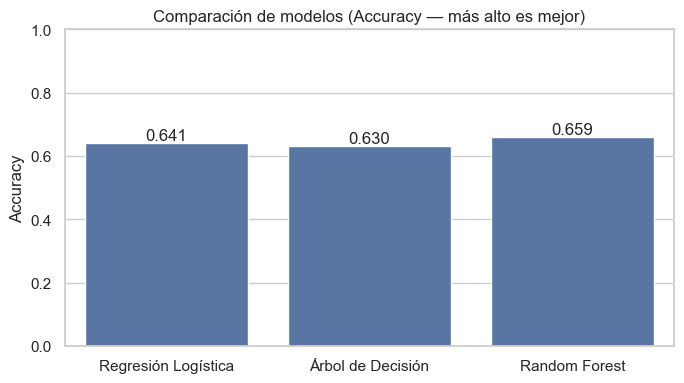

In [196]:
# Gráfico de barras comparando Accuracy
plt.figure(figsize=(7, 4))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.ylabel("Accuracy")
plt.title("Comparación de modelos (Accuracy — más alto es mejor)")
plt.ylim(0, 1)
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


In [197]:
# Paso 7: Matrices de Confusión
# TIP: Generen y visualicen la matriz de confusión para cada uno de los tres modelos utilizando sns.heatmap.
# Esto les permitirá analizar visualmente los falsos positivos y falsos negativos de cada algoritmo.

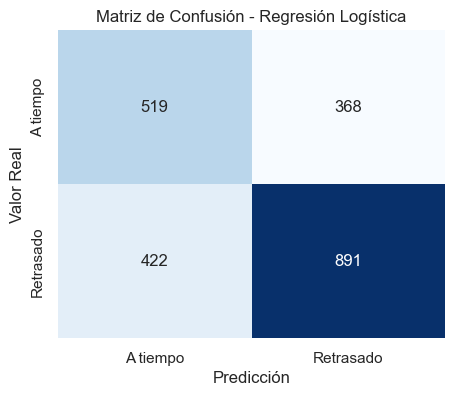

In [210]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["A tiempo", "Retrasado"],
    yticklabels=["A tiempo", "Retrasado"]
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

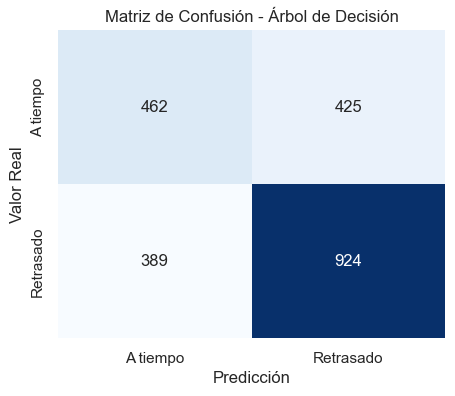

In [211]:
cm_tree = confusion_matrix(y_test, pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["A tiempo", "Retrasado"],
    yticklabels=["A tiempo", "Retrasado"]
)

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

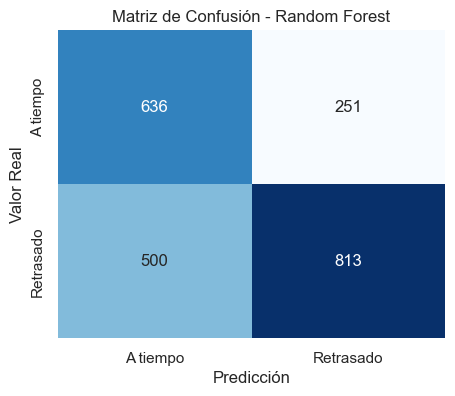

In [212]:
cm_forest = confusion_matrix(y_test, pred_forest)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_forest,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["A tiempo", "Retrasado"],
    yticklabels=["A tiempo", "Retrasado"]
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

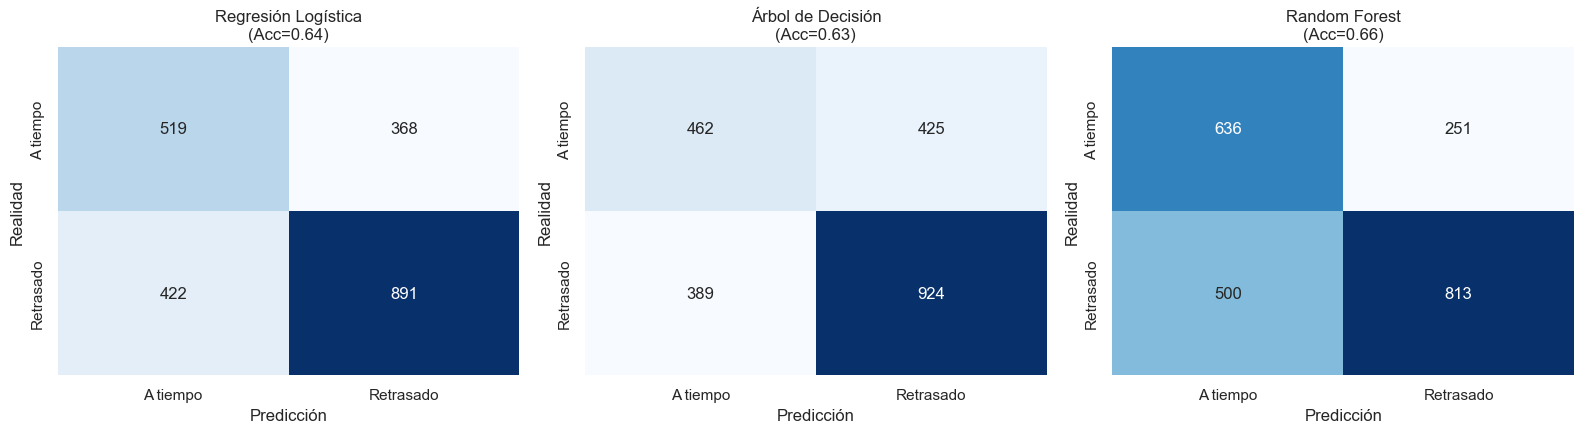

In [213]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
modelos = [("Regresión Logística", pred_log),
           ("Árbol de Decisión", pred_tree),
           ("Random Forest", pred_forest)]

for ax, (nombre, pred) in zip(axes, modelos):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["A tiempo", "Retrasado"],
                yticklabels=["A tiempo", "Retrasado"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Realidad")
    ax.set_title(f"{nombre}\n(Acc={accuracy_score(y_test, pred):.2f})")
    

plt.tight_layout()
plt.show()
